# 17 · From a messy rheometer file to a report

**Problem.** A food-technology lab has measured a tomato ketchup four ways - an amplitude sweep, a
frequency sweep, and flow curves up and down - and exported everything in one file from a
German-language rheometer PC. The customer wants a one-page report: Is the ketchup gel-like at rest? What
is its yield stress? How does it flow when squeezed from a bottle, and does it recover?

This notebook uses nearly every tool of the course, starting where real work starts: with a file that is
not ready for analysis.

**What you will learn**
- parse a multi-test rheometer export (separators, decimal commas, units, metadata)
- apply quality checks and document excluded data
- combine oscillatory and steady tests into conclusions
- write a reproducible report with uncertainties

**Before you start:** notebooks 00, 02-04, 06 and 08  ·  **Time:** about 75-90 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io
from engrheo import datasets, fitting, oscillatory
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## 1. Look at the file

In [2]:
path = datasets.path("ketchup_rheometer_export.csv")
with open(path, encoding="utf-8") as fh:
    raw_lines = fh.read().splitlines()
print(f"{len(raw_lines)} lines")
print("\n".join(raw_lines[:14]))
print("...")
print("\n".join(raw_lines[49:57]))

102 lines
Rheometer export;;;;
Sample;Ketchup (tomato ketchup, retail);;;
Operator;JM;;;
Date;14.03.2026;;;
Geometry;PP25/S (sandblasted plate, 25 mm), gap 1,000 mm;;;

Test;Amplitude sweep;;;
Temperature;25,0 °C;;;
Frequency;1 Hz;;;
Point;Strain;Storage modulus;Loss modulus;Status
;%;Pa;Pa;
1;0,01;254,72;60,452;ok
2;0,015849;253,16;61,647;ok
3;0,025119;252,13;60,199;ok
...
12;15,849;322,02;82,42;ok
13;25,119;328,54;90,556;ok
14;39,811;359,76;95,295;ok
15;63,096;388,42;102,71;ok
16;100;402,1;106,71;ok

Test;Flow curve (up);;;
Temperature;25,0 °C;;;


Several things stand out: semicolons separate the columns, decimals use commas, a units row follows each
header, the file contains four separate tests with their own metadata, and a status column flags
problems. `pd.read_csv` on the whole file would fail; the tests must be split first.

## 2. Parse the blocks

In [3]:
def parse_export(lines):
    tests, i = {}, 0
    while i < len(lines):
        if lines[i].startswith("Test;"):
            name = lines[i].split(";")[1]
            meta = {}
            i += 1
            while not lines[i].startswith("Point;"):          # metadata lines of this test
                key, value = lines[i].split(";")[:2]
                meta[key] = value
                i += 1
            header, units = lines[i].split(";"), lines[i + 1].split(";")
            columns = [f"{h} ({u})" if u else h for h, u in zip(header, units)]
            j = i + 2
            while j < len(lines) and lines[j].strip():
                j += 1
            table = pd.read_csv(io.StringIO("\n".join(lines[i + 2:j])), sep=";", decimal=",", header=None,
                                names=columns, na_values=["---"])
            tests[name] = {"meta": meta, "data": table}
            i = j
        else:
            i += 1
    return tests

tests = parse_export(raw_lines)
for name, t in tests.items():
    print(f"{name:<20} {len(t['data']):3d} points  {t['meta']}  columns: {list(t['data'].columns)[1:4]}")

Amplitude sweep       21 points  {'Temperature': '25,0 °C', 'Frequency': '1 Hz'}  columns: ['Strain (%)', 'Storage modulus (Pa)', 'Loss modulus (Pa)']
Frequency sweep       16 points  {'Temperature': '25,0 °C', 'Strain': '0,5 %'}  columns: ['Angular frequency (rad/s)', 'Storage modulus (Pa)', 'Loss modulus (Pa)']
Flow curve (up)       19 points  {'Temperature': '25,0 °C'}  columns: ['Shear rate (1/s)', 'Shear stress (Pa)', 'Viscosity (mPa·s)']
Flow curve (down)     19 points  {'Temperature': '25,0 °C'}  columns: ['Shear rate (1/s)', 'Shear stress (Pa)', 'Viscosity (mPa·s)']


## 3. Check before analysing

In [4]:
for name, t in tests.items():
    flagged = t["data"][t["data"]["Status"] != "ok"]
    if len(flagged):
        print(f"{name}:"); print(flagged.to_string(index=False)); print()
up = tests["Flow curve (up)"]["data"]
consistency = np.nanmax(np.abs(up["Viscosity (mPa·s)"] / 1000 - up["Shear stress (Pa)"] / up["Shear rate (1/s)"])
                        / (up["Shear stress (Pa)"] / up["Shear rate (1/s)"]))
print(f"viscosity column (mPa s) consistent with stress/rate to {consistency:.1e}")

Flow curve (up):
 Point  Shear rate (1/s)  Shear stress (Pa)  Viscosity (mPa·s)                   Status
     1          0.010000             25.182          2518200.0 Steady state not reached
     2          0.017783             25.744          1447700.0 Steady state not reached

Flow curve (down):
 Point  Shear rate (1/s)  Shear stress (Pa)  Viscosity (mPa·s)             Status
     7              10.0                NaN                NaN Measurement failed

viscosity column (mPa s) consistent with stress/rate to 2.5e-05


Two kinds of problem: at the lowest shear rates of the upward curve the instrument reports that steady
state was not reached - the stress was still decaying when the point was recorded, so it reads too high -
and one point of the downward curve failed completely. Both are excluded, and the decision is recorded. The
viscosity column is in mPa·s, not Pa·s - a factor of 1000 that the units row reveals.

## 4. At rest: amplitude and frequency sweeps

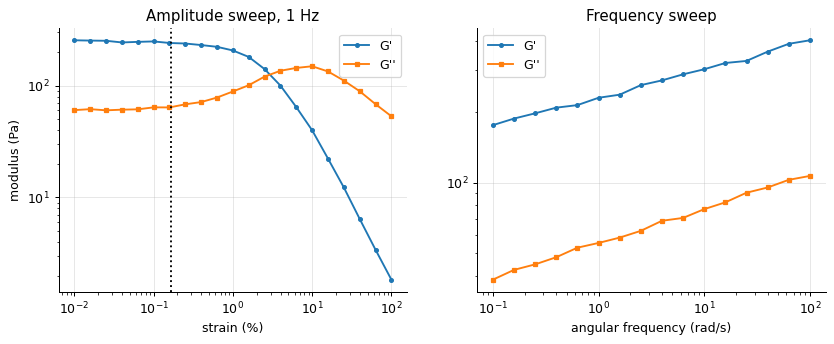

linear range up to 0.17 % strain; flow point at 2.9 % strain, stress 5.2 Pa
frequency sweep: G' > G'' everywhere: True; tan(delta) 0.22-0.28; G' ~ omega^0.12


In [5]:
amp = tests["Amplitude sweep"]["data"]
strain = amp["Strain (%)"].to_numpy() / 100
Gp, Gpp = amp["Storage modulus (Pa)"].to_numpy(), amp["Loss modulus (Pa)"].to_numpy()
lve = oscillatory.lve_limit(strain, Gp)
flow_strain, flow_G = oscillatory.crossover(strain, Gp, Gpp)
tau_flowpoint = np.hypot(flow_G, flow_G) * flow_strain             # |G*| x strain at the crossover
frq = tests["Frequency sweep"]["data"]
w = frq["Angular frequency (rad/s)"].to_numpy()
tan_d = frq["Loss modulus (Pa)"] / frq["Storage modulus (Pa)"]
slope = np.polyfit(np.log(w), np.log(frq["Storage modulus (Pa)"]), 1)[0]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.loglog(strain * 100, Gp, "o-", ms=3, label="G'"); a1.loglog(strain * 100, Gpp, "s-", ms=3, label="G''")
a1.axvline(lve * 100, color="k", ls=":"); a1.set(xlabel="strain (%)", ylabel="modulus (Pa)", title="Amplitude sweep, 1 Hz"); a1.legend()
a2.loglog(w, frq["Storage modulus (Pa)"], "o-", ms=3, label="G'"); a2.loglog(w, frq["Loss modulus (Pa)"], "s-", ms=3, label="G''")
a2.set(xlabel="angular frequency (rad/s)", title="Frequency sweep"); a2.legend(); plt.show()
print(f"linear range up to {lve*100:.2f} % strain; flow point at {flow_strain*100:.1f} % strain, stress {tau_flowpoint:.1f} Pa")
print(f"frequency sweep: G' > G'' everywhere: {bool(np.all(tan_d < 1))}; tan(delta) {tan_d.min():.2f}-{tan_d.max():.2f}; "
      f"G' ~ omega^{slope:.2f}")

At rest the ketchup is a **weak gel**: $G'$ exceeds $G''$ at all frequencies and depends only weakly on frequency.
The amplitude sweep shows how much deformation the structure tolerates before it yields.

## 5. When it flows: flow curves

herschel_bulkley fit to 17 points: relative scatter 1.96 %, AIC -130.91
parameter    value  std. error  95% low  95% high
-------------------------------------------------
    tau_y    14.95     0.32644    14.25     15.65
        K   4.6721     0.35724   3.9059    5.4383
        n  0.34077    0.013911  0.31093    0.3706

herschel_bulkley fit to 18 points: relative scatter 2.18 %, AIC -135.04
parameter    value  std. error  95% low  95% high
-------------------------------------------------
    tau_y   13.508     0.21399   13.052    13.964
        K    3.602     0.26009   3.0477    4.1564
        n  0.38356    0.013847  0.35404   0.41307


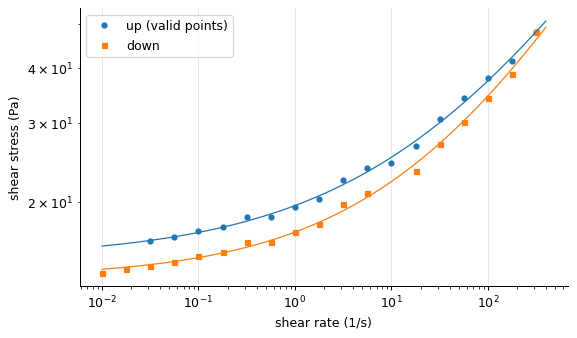

thixotropic loop area 781 Pa/s; down-curve yield stress -10% relative to up


In [6]:
def valid(block):
    d = tests[block]["data"]
    d = d[(d["Status"] == "ok") & d["Shear stress (Pa)"].notna()].sort_values("Shear rate (1/s)")
    return d["Shear rate (1/s)"].to_numpy(), d["Shear stress (Pa)"].to_numpy()

r_up, t_up = valid("Flow curve (up)")
r_dn, t_dn = valid("Flow curve (down)")
hb_up = fitting.fit_flow_curve(r_up, t_up, "herschel_bulkley")
hb_dn = fitting.fit_flow_curve(r_dn, t_dn, "herschel_bulkley")
print(hb_up); print(); print(hb_dn)
rr = np.logspace(-2, 2.6, 200)
plt.loglog(r_up, t_up, "o", ms=4, label="up (valid points)"); plt.loglog(r_dn, t_dn, "s", ms=4, label="down")
plt.loglog(rr, hb_up.predict_stress(rr), "C0-", lw=1); plt.loglog(rr, hb_dn.predict_stress(rr), "C1-", lw=1)
plt.xlabel("shear rate (1/s)"); plt.ylabel("shear stress (Pa)"); plt.legend(); plt.show()
x = np.r_[r_up, r_dn[::-1]]; y = np.r_[t_up, t_dn[::-1]]
loop = 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))
print(f"thixotropic loop area {loop:.0f} Pa/s; down-curve yield stress {hb_dn.params['tau_y']/hb_up.params['tau_y'] - 1:+.0%} relative to up")

The downward curve lies below the upward one - shear has broken down part of the structure (notebook 06).

## 6. How strong is it? Three yield-stress estimates

In [7]:
estimates = pd.DataFrame({
    "method": ["Herschel-Bulkley, up curve (extrapolated)", "Herschel-Bulkley, down curve (extrapolated)",
               "flow point of the amplitude sweep (G' = G'')"],
    "yield stress (Pa)": [hb_up.params["tau_y"], hb_dn.params["tau_y"], tau_flowpoint],
    "95 % interval (Pa)": [f"{hb_up.conf_int()['tau_y'][0]:.1f} - {hb_up.conf_int()['tau_y'][1]:.1f}",
                           f"{hb_dn.conf_int()['tau_y'][0]:.1f} - {hb_dn.conf_int()['tau_y'][1]:.1f}", "-"]})
print(estimates.round(1).to_string(index=False))

                                      method  yield stress (Pa) 95 % interval (Pa)
   Herschel-Bulkley, up curve (extrapolated)               14.9        14.2 - 15.6
 Herschel-Bulkley, down curve (extrapolated)               13.5        13.1 - 14.0
flow point of the amplitude sweep (G' = G'')                5.2                  -


The estimates differ, and they should: each measures something different (notebook 04). The up-curve fit
describes the undisturbed product, the down curve the product after shearing, and the flow point the
stress at which the gel structure gives way in oscillation. A report must say which one it quotes.

## 7. The report

In [8]:
import tempfile
from pathlib import Path
out = Path(tempfile.gettempdir()) / "ketchup_report"
out.mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(r_up, t_up, "o", label="measured (up)"); ax.loglog(rr, hb_up.predict_stress(rr), label="Herschel-Bulkley fit")
ax.set(xlabel="shear rate (1/s)", ylabel="shear stress (Pa)", title="Ketchup, 25 degC"); ax.legend()
fig.savefig(out / "flow_curve.png", dpi=150, bbox_inches="tight"); plt.close(fig)
p = hb_up.params; ci = hb_up.conf_int()
report = f'''# Rheology report - tomato ketchup, 25 degC

**At rest:** weak gel (G' > G'' from {w.min():g} to {w.max():g} rad/s, tan(delta) {tan_d.min():.2f}-{tan_d.max():.2f});
linear up to {lve*100:.1f} % strain; structure yields at {flow_strain*100:.0f} % strain ({tau_flowpoint:.0f} Pa).

**Flow (Herschel-Bulkley, upward flow curve, {len(r_up)} valid points):** yield stress {p['tau_y']:.1f} Pa
(95 % CI {ci['tau_y'][0]:.1f}-{ci['tau_y'][1]:.1f}), K = {p['K']:.2f} Pa s^n, n = {p['n']:.2f}.

**Thixotropy:** after shearing the yield stress is {abs(hb_dn.params['tau_y']/p['tau_y'] - 1):.0%} lower (loop area {loop:.0f} Pa/s).

**Data handling:** {int((up['Status'] != 'ok').sum())} upward points excluded (steady state not reached),
1 downward point excluded (measurement failed). Figure: flow_curve.png.
'''
(out / "report.md").write_text(report, encoding="utf-8")
print(report)

# Rheology report - tomato ketchup, 25 degC

**At rest:** weak gel (G' > G'' from 0.1 to 100 rad/s, tan(delta) 0.22-0.28);
linear up to 0.2 % strain; structure yields at 3 % strain (5 Pa).

**Flow (Herschel-Bulkley, upward flow curve, 17 valid points):** yield stress 14.9 Pa
(95 % CI 14.2-15.6), K = 4.67 Pa s^n, n = 0.34.

**Thixotropy:** after shearing the yield stress is 10% lower (loop area 781 Pa/s).

**Data handling:** 2 upward points excluded (steady state not reached),
1 downward point excluded (measurement failed). Figure: flow_curve.png.



The report states results *with* their uncertainty, names the methods, and records every data-handling
decision - so that anyone can reproduce it from the raw file. The whole analysis is a script: when next
week's batch is measured, it runs again unchanged.

(The file is synthetic, generated from a Herschel-Bulkley ketchup with $\tau_y$ = 15 Pa, $K$ = 4.5 Pa·s$^n$ and
$n$ = 0.35 - compare the report with these values.)

## Inside the algorithm: the yield stress at the flow point by hand
At the crossover $G' = G''$, so $|G^*| = \sqrt 2\,G'$; the stress amplitude there is $|G^*|\gamma_0$. Interpolate the crossover
on log scales between the two bracketing points:

In [9]:
d = np.log(Gp) - np.log(Gpp)
i = np.nonzero(np.sign(d[:-1]) != np.sign(d[1:]))[0][0]
f = d[i] / (d[i] - d[i + 1])
g_c = np.exp(np.log(strain[i]) + f * np.log(strain[i + 1] / strain[i]))
G_c = np.exp(np.log(Gp[i]) + f * np.log(Gp[i + 1] / Gp[i]))
print(f"by hand: flow point at {g_c*100:.2f} % strain, stress {np.sqrt(2)*G_c*g_c:.2f} Pa;  notebook: {tau_flowpoint:.2f} Pa")

by hand: flow point at 2.93 % strain, stress 5.20 Pa;  notebook: 5.20 Pa


## Exercises
1. Refit the upward flow curve *including* the two points flagged 'steady state not reached'. How much do the yield stress and its confidence interval change? Why is excluding them justified - and why must the exclusion be reported?
2. The ketchup must flow from a squeezed bottle but not run off a plate. Which of the three yield-stress estimates is most relevant to each requirement? Compare all three with the true value (15 Pa).
3. **Implement it yourself:** turn the parsing and the checks into one reusable function `load_export(path)` that returns the tests as DataFrames with SI units (Pa·s instead of mPa·s, strain as a fraction) and a list of excluded points, and test it on the file.